In [1]:
from astroquery.gaia import Gaia

job = Gaia.launch_job("SELECT TOP 10 * FROM gaiadr3.gaia_source")
results = job.get_results()

results.to_pandas().head()

The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


,solution_id,designation,source_id,random_index,ref_epoch,ra,ra_error,dec,dec_error,parallax,...,azero_gspphot,azero_gspphot_lower,azero_gspphot_upper,ag_gspphot,ag_gspphot_lower,ag_gspphot_upper,ebpminrp_gspphot,ebpminrp_gspphot_lower,ebpminrp_gspphot_upper,libname_gspphot
0,1636148068921376768,Gaia DR3 1374389600384,1374389600384,866663434,2016.0,44.932802,0.134052,0.064809,0.116465,1.765055,...,0.4993,0.4523,0.5627,0.3329,0.3016,0.3757,0.1986,0.1802,0.2236,MARCS
1,1636148068921376768,Gaia DR3 3607772690688,3607772690688,1702304094,2016.0,45.031825,0.201430,0.144176,0.186554,1.428901,...,0.0397,0.0099,0.0843,0.0275,0.0068,0.0583,0.0153,0.0038,0.0325,PHOENIX
2,1636148068921376768,Gaia DR3 4294967463680,4294967463680,1222468863,2016.0,45.099634,2.047677,0.196585,1.557588,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
3,1636148068921376768,Gaia DR3 5295694864384,5295694864384,974969,2016.0,44.925444,19.684959,0.149559,11.315668,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
4,1636148068921376768,Gaia DR3 6807523466752,6807523466752,532478203,2016.0,45.012984,0.441595,0.179128,0.421982,-0.310563,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,


In [2]:
from astroquery.gaia import Gaia

query = """
SELECT TOP 5000
    ra, dec,
    parallax,
    parallax_error,
    phot_g_mean_mag
FROM gaiadr3.gaia_source
WHERE parallax > 1
"""

job = Gaia.launch_job(query)
df = job.get_results().to_pandas()

In [5]:
import numpy as np

# Remove bad measurements
df = df[df["parallax"] > 0]
df = df[df["parallax_error"] / df["parallax"] < 0.2]

In [6]:
df["distance_pc"] = 1 / df["parallax"]

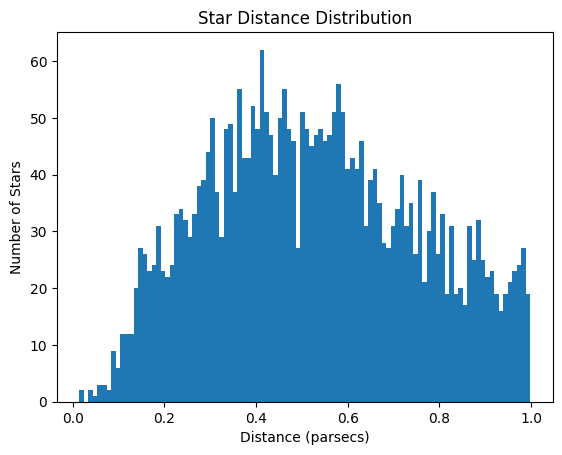

In [7]:
import matplotlib.pyplot as plt

plt.hist(df["distance_pc"], bins=100)
plt.xlabel("Distance (parsecs)")
plt.ylabel("Number of Stars")
plt.title("Star Distance Distribution")
plt.show()

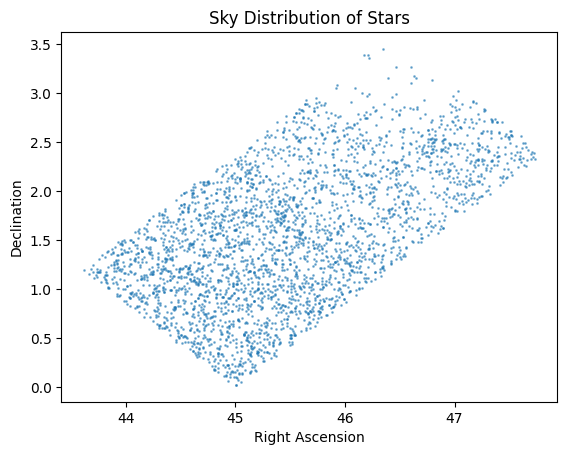

In [8]:
plt.scatter(df["ra"], df["dec"], s=1, alpha=0.5)
plt.xlabel("Right Ascension")
plt.ylabel("Declination")
plt.title("Sky Distribution of Stars")
plt.show()

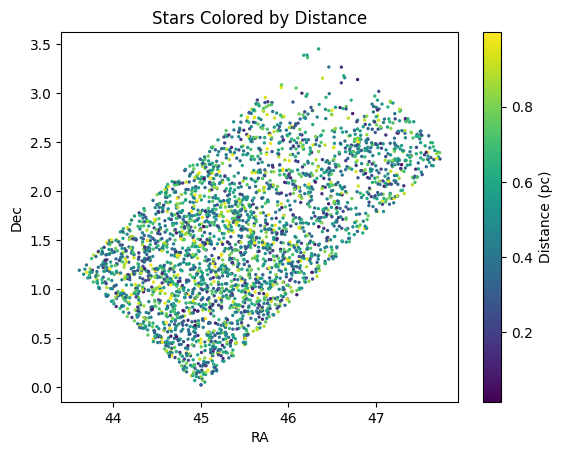

In [9]:
plt.scatter(df["ra"], df["dec"], c=df["distance_pc"], s=2, cmap="viridis")
plt.colorbar(label="Distance (pc)")
plt.xlabel("RA")
plt.ylabel("Dec")
plt.title("Stars Colored by Distance")
plt.show()

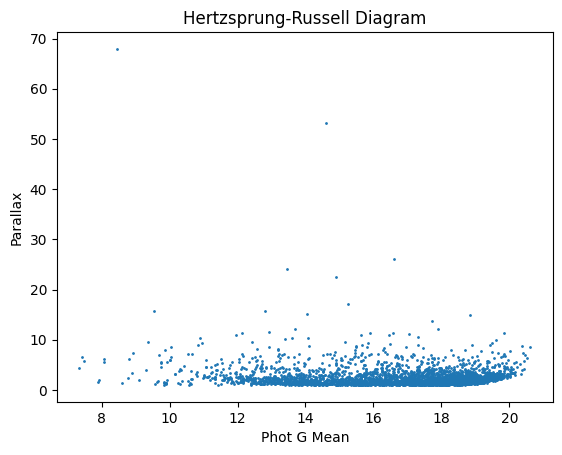

In [11]:
plt.scatter(df["phot_g_mean_mag"], df["parallax"], s=1)
plt.xlabel("Phot G Mean")
plt.ylabel("Parallax")
plt.title("Hertzsprung-Russell Diagram")
plt.show()

In [12]:
df["x"] = df["distance_pc"] * np.cos(np.radians(df["dec"])) * np.cos(np.radians(df["ra"]))
df["y"] = df["distance_pc"] * np.cos(np.radians(df["dec"])) * np.sin(np.radians(df["ra"]))
df["z"] = df["distance_pc"] * np.sin(np.radians(df["dec"]))